This notebook demonstrates that the log-sum-exp approximation is a sound surrogate of the margin between the maximum logit of a safe action and the maximum logit of an unsafe action:

\begin{equation*}
    m(s, \pi) = \max_{a \in \mathcal{A}_{\text{safe}}} z_K(s, a) - \max_{a' \in \mathcal{A}_{\text{unsafe}}} z_K(s, a') \approx \tau \left( \log\left( \sum_{a \in \mathcal{A}_{\text{safe}}} e^{z_K(s, a)/\tau} \right) - \log\left( \sum_{a' \in \mathcal{A}_{\text{unsafe}}} e^{z_K(s, a')/\tau} \right) \right)
\end{equation*}

where:
- $z_K(s ,a)$ is the logit of action $a$ in state $s$ at the final layer $K$ of the policy neural network;
- $\tau$ is a temperature parameter that controls the tightness of the approximation. As $\tau \to 0$, the log-sum-exp approximation converges to the true margin. In practice, we can use a small but non-zero $\tau$ to get a smooth surrogate that is easier to optimize while still closely approximating the true margin.

In [3]:
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
logits = numpy.array([-2.0, -1.0, 0.0, 1.0, 2.0])
safe_action_indices = [0, 1, 2]
unsafe_action_indices = [3, 4]

In [5]:
def safety_specification(logits, safe_action_indices, unsafe_action_indices):
    max_safe_logit = numpy.max(logits[safe_action_indices])
    max_unsafe_logit = numpy.max(logits[unsafe_action_indices])
    return max_safe_logit > max_unsafe_logit

def safety_logit_margin(logits, safe_action_indices, unsafe_action_indices):
    max_safe_logit = numpy.max(logits[safe_action_indices])
    max_unsafe_logit = numpy.max(logits[unsafe_action_indices])
    return max_safe_logit - max_unsafe_logit

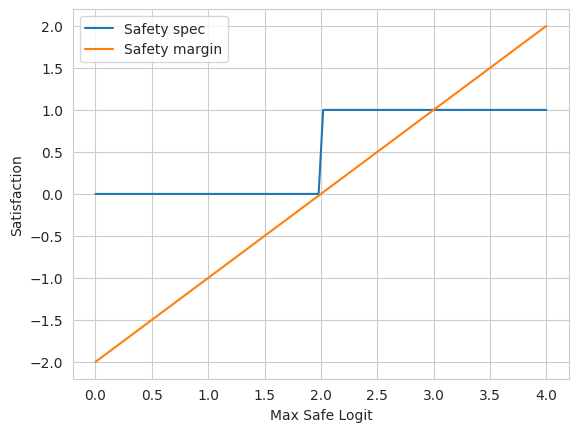

In [10]:
max_safe_logit = numpy.max(logits[safe_action_indices])
max_safe_logit_argmax = numpy.argmax(logits[safe_action_indices])
max_unsafe_logit = numpy.max(logits[unsafe_action_indices])

max_safe_logit_values = numpy.linspace(start=max_safe_logit, stop=max_unsafe_logit*2, num=100)

# Calculate safety spec and safety margin
safety_spec_values = []
safety_margin_values = []
for cur_max_safe_logit in max_safe_logit_values:
    cur_logits = logits.copy()
    cur_logits[safe_action_indices[max_safe_logit_argmax]] = cur_max_safe_logit
    # Safety spec:
    spec_satisfied = safety_specification(cur_logits, safe_action_indices, unsafe_action_indices)
    safety_spec_values.append(spec_satisfied)
    # Safety margin:
    margin = safety_logit_margin(cur_logits, safe_action_indices, unsafe_action_indices)
    safety_margin_values.append(margin)


plt.plot(max_safe_logit_values, safety_spec_values, label='Safety spec')
plt.plot(max_safe_logit_values, safety_margin_values, label='Safety margin')
plt.xlabel('Max Safe Logit')
plt.ylabel('Satisfaction')
plt.legend()
plt.show()

Both are non-differentiable due to the max operator. Let's use the log-sum-exp approximation to get a differentiable surrogate for the safety specification.

In [34]:
def log_sum_exp(logits, indices, inverse_temperature=10):
    tau = 1 / inverse_temperature
    return tau * numpy.log(numpy.sum(numpy.exp(logits[indices]/tau)))

In [35]:
log_sum_exp(logits=logits, indices=safe_action_indices)

np.float64(4.54009602769886e-06)

In [36]:
logsumexp_margin_values_dct = {}
for inverse_temperature in [0.1, 1]:
    logsumexp_margin_values_dct[inverse_temperature] = []
    for cur_max_safe_logit in max_safe_logit_values:
        cur_logits = logits.copy()
        cur_logits[safe_action_indices[max_safe_logit_argmax]] = cur_max_safe_logit
        
        safe_logsumexp = log_sum_exp(cur_logits, safe_action_indices, inverse_temperature=inverse_temperature)
        unsafe_logsumexp = log_sum_exp(cur_logits, unsafe_action_indices, inverse_temperature=inverse_temperature)
        margin = safe_logsumexp - unsafe_logsumexp
        logsumexp_margin_values_dct[inverse_temperature].append(margin)

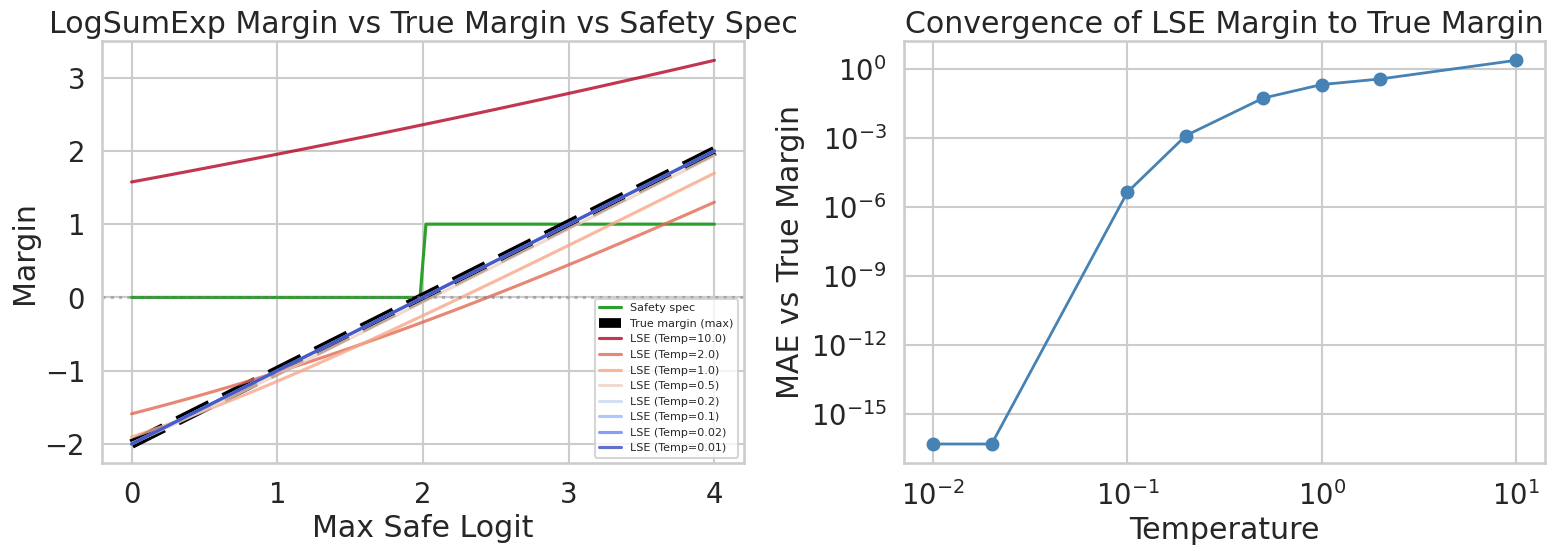

In [56]:
inverse_temperatures = [0.1, 0.5, 1, 2, 5, 10, 50, 100]
sns.set_context("talk", font_scale=1.2)

logsumexp_margin_values_dct = {}
for inverse_temperature in inverse_temperatures:
    logsumexp_margin_values_dct[inverse_temperature] = []
    for cur_max_safe_logit in max_safe_logit_values:
        cur_logits = logits.copy()
        cur_logits[safe_action_indices[max_safe_logit_argmax]] = cur_max_safe_logit
        
        safe_logsumexp = log_sum_exp(cur_logits, safe_action_indices, inverse_temperature=inverse_temperature)
        unsafe_logsumexp = log_sum_exp(cur_logits, unsafe_action_indices, inverse_temperature=inverse_temperature)
        margin = safe_logsumexp - unsafe_logsumexp
        logsumexp_margin_values_dct[inverse_temperature].append(margin)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: all curves overlaid
ax = axes[0]
ax.plot(max_safe_logit_values, safety_spec_values, color='tab:green', label='Safety spec')
ax.plot(max_safe_logit_values, safety_margin_values, label='True margin (max)', color='black', linewidth=7, linestyle='--')
cmap = plt.cm.coolwarm
for i, inverse_temperature in enumerate(inverse_temperatures):
    j = len(inverse_temperatures) - 1 - i
    color = cmap(j / (len(inverse_temperatures) - 1))
    ax.plot(max_safe_logit_values, logsumexp_margin_values_dct[inverse_temperature],
            label=f'LSE (Temp={round(1/inverse_temperature, 2)})', color=color, alpha=0.8)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Max Safe Logit')
ax.set_ylabel('Margin')
ax.set_title('LogSumExp Margin vs True Margin vs Safety Spec')
ax.legend(loc='lower right', fontsize=8)

# Right plot: mean absolute error vs inverse_temperature
mae_values = []
for inverse_temperature in inverse_temperatures:
    mae = numpy.mean(numpy.abs(numpy.array(logsumexp_margin_values_dct[inverse_temperature]) - numpy.array(safety_margin_values)))
    mae_values.append(mae)

ax2 = axes[1]
temperatures = 1 / numpy.array(inverse_temperatures)
ax2.plot(temperatures, mae_values, marker='o', color='steelblue', linewidth=2)
ax2.set_xlabel('Temperature')
ax2.set_ylabel('MAE vs True Margin')
ax2.set_title('Convergence of LSE Margin to True Margin')
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

Illustration of the log-exp-sum surrogate (differentiable) for the safety logit margin (non-differentiable) and the boolean operator (safety spec) that is used to check the policy's safety in a state $s$.